     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.0 MB/s eta 0:00:00
Mounted at /content/drive
Label counts:
 label
0    154
1    159
Name: count, dtype: int64

Sensitive counts:
 sensitive
0    230
1     83
Name: count, dtype: int64

=== FairGNN sweep: lambda=0.0 ===

=== Group stats (seed first) ===
train | s=0 count=137  y=1 count=71  y=0 count=66
train | s=1 count=50  y=1 count=24  y=0 count=26
val | s=0 count=46  y=1 count=24  y=0 count=22
val | s=1 count=17  y=1 count=8  y=0 count=9
test | s=0 count=47  y=1 count=24  y=0 count=23
test | s=1 count=16  y=1 count=8  y=0 count=8
lambda=0.0  | seed 00 | acc=0.794 | ΔSP=0.033 | ΔEO=0.333 | best_epoch=10
lambda=0.0  | seed 01 | acc=0.746 | ΔSP=0.027 | ΔEO=0.042 | best_epoch=6
lambda=0.0  | seed 02 | acc=0.635 | ΔSP=0.157 | ΔEO=0.167 | best_epoch=19
lambda=0.0  | seed 03 | acc=0.714 | ΔSP=0.070 | ΔEO=0.125 | best_epoch=8
lambda=0.0  | seed 04 | acc=0.

,seed,best_epoch,test_acc,test_dsp,test_deo,lambda_grl,use_adversary
0,0,10,0.793651,0.033245,0.333333,0.0,True
1,1,6,0.746032,0.026854,0.041667,0.0,True
2,2,19,0.634921,0.156915,0.166667,0.0,True
3,3,8,0.714286,0.070479,0.125000,0.0,True
4,4,25,0.714286,0.179521,0.208333,0.0,True


,lambda_grl,acc_mean,acc_std,dsp_mean,dsp_std,deo_mean,deo_std
0,0.0,0.722222,0.070690,0.092280,0.066046,0.187500,0.126152
1,0.1,0.726984,0.065146,0.070278,0.052275,0.158333,0.099768
2,0.2,0.725397,0.060350,0.076435,0.047745,0.141667,0.086066
3,0.5,0.712698,0.076473,0.102710,0.065410,0.179167,0.090117
4,1.0,0.701587,0.062515,0.088219,0.061204,0.125000,0.068041
5,2.0,0.719048,0.059415,0.161975,0.069272,0.195833,0.107673



Saved: nba_fairgnn_sweep_all.csv
Saved: nba_fairgnn_sweep_summary.csv


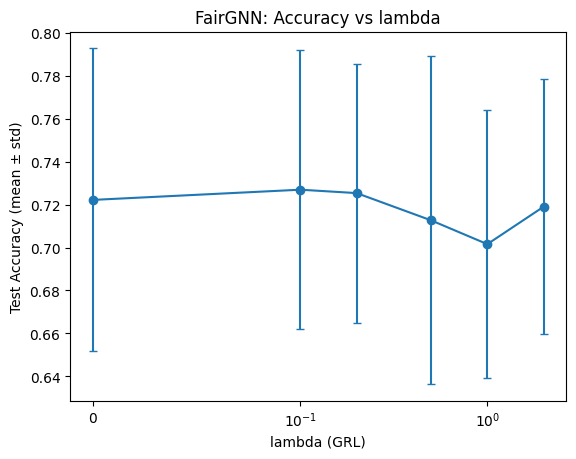

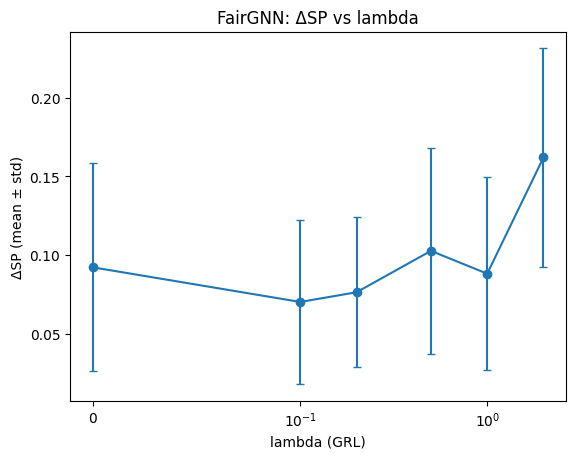

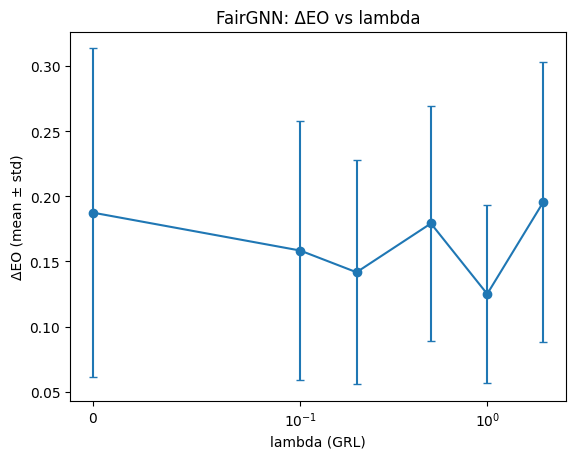

,lambda,mean(ΔAcc_vs0),CI95(ΔAcc_vs0),mean(ΔΔSP_vs0),CI95(ΔΔSP_vs0),mean(ΔΔEO_vs0),CI95(ΔΔEO_vs0)
0,0.0,0.000000,"(0.0, 0.0)",0.000000,"(0.0, 0.0)",0.000000,"(0.0, 0.0)"
1,0.1,0.004762,"(-0.00952380895614624, 0.02698412537574768)",-0.022003,"(-0.05288507044315338, 0.005390912294387817)",-0.029167,"(-0.06250000596046448, 0.004166644811630249)"
2,0.2,0.003175,"(-0.02063491940498352, 0.0317460298538208)",-0.015845,"(-0.049265727400779724, 0.01956997811794281)",-0.045833,"(-0.10416666865348816, 0.008333331346511841)"
3,0.5,-0.009524,"(-0.031746047735214236, 0.012698405981063842)",0.010429,"(-0.04263209998607635, 0.06386304311454291)",-0.008333,"(-0.07916667461395263, 0.062499994039535524)"
4,1.0,-0.020635,"(-0.04920636415481568, 0.003174620866775513)",-0.004062,"(-0.06682977274060249, 0.057226325646042624)",-0.062500,"(-0.12083335518836975, -0.012500014901161195)"
5,2.0,-0.003175,"(-0.020674601644277535, 0.014285725355148316)",0.069694,"(0.017682114988565447, 0.12741576910018912)",0.008333,"(-0.07083337306976319, 0.08333332538604736)"


Saved: nba_fairgnn_sweep_paired_vs0.csv

=== Optional Ablation: No adversary (use_adversary=False) ===


,use_adversary,acc_mean,acc_std,dsp_mean,dsp_std,deo_mean,deo_std
0,False,0.722222,0.07069,0.09228,0.066046,0.1875,0.126152


Saved: nba_fairgnn_ablation_noadv.csv


In [ ]:
# =========================
# 0) Install
# =========================
%pip install -q torch torchvision torchaudio
%pip install -q torch-geometric
%pip install -q scikit-learn pandas numpy matplotlib

# =========================
# 1) Imports + utils
# =========================
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from google.colab import drive
drive.mount('/content/drive')

def set_global_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# =========================
# 2) Load & preprocess NBA dataset
# =========================
csv_path = "/content/drive/MyDrive/courses/network/NBA/dataset/nba.csv"
edge_path = "/content/drive/MyDrive/courses/network/NBA/dataset/nba_relationship.txt"

nodes = pd.read_csv(csv_path)

# Drop unknown labels
nodes["SALARY"] = pd.to_numeric(nodes["SALARY"], errors="coerce")
nodes = nodes[nodes["SALARY"].notna() & (nodes["SALARY"] != -1)].copy()

# Label: salary > 0 (same as your baseline)
nodes["label"] = (nodes["SALARY"] > 0).astype(int)

# Sensitive attribute: country (binary)
country = pd.to_numeric(nodes["country"], errors="coerce").fillna(0)
nodes["sensitive"] = (country > 0).astype(int)

feature_cols = [
    c for c in nodes.columns
    if c not in ["user_id", "SALARY", "country", "label", "sensitive"]
]

print("Label counts:\n", nodes["label"].value_counts().sort_index())
print("\nSensitive counts:\n", nodes["sensitive"].value_counts().sort_index())

edges = pd.read_csv(edge_path, sep="\t", names=["src", "dst"])

# =========================
# 3) Stratified split masks (by (y, sensitive))
# =========================
def make_stratified_masks(y: torch.Tensor, s: torch.Tensor,
                          train_ratio=0.6, val_ratio=0.2, seed=0):
    y_np = y.cpu().numpy()
    s_np = s.cpu().numpy()
    strata = y_np * 2 + s_np  # 0..3

    idx_all = np.arange(len(y_np))

    sss1 = StratifiedShuffleSplit(n_splits=1, train_size=train_ratio, random_state=seed)
    train_idx, temp_idx = next(sss1.split(idx_all, strata))

    temp_strata = strata[temp_idx]
    val_size_rel = val_ratio / (1 - train_ratio)

    sss2 = StratifiedShuffleSplit(n_splits=1, train_size=val_size_rel, random_state=seed)
    val_rel, test_rel = next(sss2.split(temp_idx, temp_strata))

    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    n = len(y_np)
    train_mask = torch.zeros(n, dtype=torch.bool)
    val_mask = torch.zeros(n, dtype=torch.bool)
    test_mask = torch.zeros(n, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    return train_mask, val_mask, test_mask

def print_group_stats(y, s, mask, name):
    y_m = y[mask].cpu().numpy()
    s_m = s[mask].cpu().numpy()
    for sv in [0, 1]:
        idx = (s_m == sv)
        print(f"{name} | s={sv} count={idx.sum()}  y=1 count={(y_m[idx]==1).sum()}  y=0 count={(y_m[idx]==0).sum()}")

# =========================
# 4) Build PyG Data (train-only scaler, undirected graph)
# =========================
def build_data(nodes_df: pd.DataFrame, edges_df: pd.DataFrame,
               feature_cols, seed=0):
    y = torch.tensor(nodes_df["label"].values, dtype=torch.long)
    s = torch.tensor(nodes_df["sensitive"].values, dtype=torch.long)

    train_mask, val_mask, test_mask = make_stratified_masks(y, s, seed=seed)

    # Train-only scaler fit (avoid leakage)
    X_np = nodes_df[feature_cols].values
    scaler = StandardScaler()
    X_scaled = X_np.copy()

    train_idx = train_mask.numpy()
    X_scaled[train_idx] = scaler.fit_transform(X_np[train_idx])
    X_scaled[~train_idx] = scaler.transform(X_np[~train_idx])

    X = torch.tensor(X_scaled, dtype=torch.float)

    # Map user_id to 0..N-1
    id_map = {uid: i for i, uid in enumerate(nodes_df["user_id"].values)}

    src_list, dst_list = [], []
    for src, dst in zip(edges_df["src"], edges_df["dst"]):
        if src in id_map and dst in id_map:
            src_list.append(id_map[src])
            dst_list.append(id_map[dst])

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)  # undirected

    data = Data(x=X, edge_index=edge_index, y=y)
    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask
    data.sensitive = s
    return data

# =========================
# 5) Fairness metrics: ΔSP, ΔEO
# =========================
@torch.no_grad()
def fairness_metrics(y_true, y_pred, sensitive):
    def safe_mean(mask):
        return y_pred[mask].float().mean() if mask.any() else torch.tensor(float("nan"))

    p1_s0 = safe_mean(sensitive == 0)
    p1_s1 = safe_mean(sensitive == 1)

    tpr_s0 = safe_mean((sensitive == 0) & (y_true == 1))
    tpr_s1 = safe_mean((sensitive == 1) & (y_true == 1))

    delta_sp = torch.abs(p1_s0 - p1_s1)
    delta_eo = torch.abs(tpr_s0 - tpr_s1)
    return float(delta_sp), float(delta_eo)

# =========================
# 6) Gradient Reversal Layer (GRL)
# =========================
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None

class GRL(torch.nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = float(lambda_)

    def set_lambda(self, lambda_):
        self.lambda_ = float(lambda_)

    def forward(self, x):
        return GradReverse.apply(x, self.lambda_)

# =========================
# 7) Models: Encoder + Heads
# =========================
class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class FairGNN(torch.nn.Module):
    """
    FairGNN (simplified): learn embeddings for y prediction while
    adversary tries to predict sensitive s from embeddings.
    GRL makes encoder learn s-invariant representation.
    """
    def __init__(self, in_channels, hidden_dim=64, dropout=0.5, lambda_grl=1.0,
                 use_adversary=True):
        super().__init__()
        self.encoder = GCNEncoder(in_channels, hidden_channels=hidden_dim, dropout=dropout)
        self.y_head = torch.nn.Linear(hidden_dim, 2)
        self.use_adversary = use_adversary

        self.grl = GRL(lambda_grl)
        # adversary predicts sensitive (binary)
        self.s_head = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, 2)
        )

    def set_lambda(self, lambda_grl):
        self.grl.set_lambda(lambda_grl)

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        y_logits = self.y_head(z)

        if self.use_adversary:
            z_rev = self.grl(z)
            s_logits = self.s_head(z_rev)
        else:
            s_logits = None
        return y_logits, s_logits, z

@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    y_logits, _, _ = model(data.x, data.edge_index)
    pred = y_logits.argmax(dim=1)
    acc = (pred[mask] == data.y[mask]).float().mean().item()
    dsp, deo = fairness_metrics(data.y[mask], pred[mask], data.sensitive[mask])
    return acc, dsp, deo

# =========================
# 8) Train one run (FairGNN) with early stopping on val acc
# =========================
def train_one_run_fairgnn(
    data: Data,
    seed: int,
    lambda_grl: float,
    use_adversary: bool = True,
    max_epochs: int = 500,
    patience: int = 50,
    lr: float = 0.01,
    weight_decay: float = 5e-4,
    hidden_dim: int = 64,
    dropout: float = 0.5,
    adv_weight: float = 1.0,   # weight for adversary CE loss
):
    set_global_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data = data.to(device)

    model = FairGNN(
        in_channels=data.num_features,
        hidden_dim=hidden_dim,
        dropout=dropout,
        lambda_grl=lambda_grl,
        use_adversary=use_adversary
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    ce = torch.nn.CrossEntropyLoss()

    best_state = None
    best_val = -1.0
    best_epoch = 0
    bad = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        opt.zero_grad()

        y_logits, s_logits, _ = model(data.x, data.edge_index)

        loss_y = ce(y_logits[data.train_mask], data.y[data.train_mask])

        if use_adversary:
            loss_s = ce(s_logits[data.train_mask], data.sensitive[data.train_mask])
            loss = loss_y + adv_weight * loss_s
        else:
            loss = loss_y

        loss.backward()
        opt.step()

        val_acc, _, _ = evaluate(model, data, data.val_mask)
        if val_acc > best_val + 1e-4:
            best_val = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    model.load_state_dict(best_state)
    test_acc, test_dsp, test_deo = evaluate(model, data, data.test_mask)

    return {
        "best_epoch": best_epoch,
        "test_acc": test_acc,
        "test_dsp": test_dsp,
        "test_deo": test_deo,
        "lambda_grl": lambda_grl,
        "use_adversary": use_adversary,
    }

# =========================
# 9) Run lambda sweep (same seeds 0..9)
# =========================
SEEDS = list(range(10))  # keep consistent with your other NBA notebooks

LAMBDA_GRID = [0.0, 0.1, 0.2, 0.5, 1.0, 2.0]  # you can extend: 5.0, 10.0

all_rows = []
for lam in LAMBDA_GRID:
    print(f"\n=== FairGNN sweep: lambda={lam} ===")
    for sd in SEEDS:
        data = build_data(nodes, edges, feature_cols, seed=sd)

        if lam == LAMBDA_GRID[0] and sd == SEEDS[0]:
            print("\n=== Group stats (seed first) ===")
            print_group_stats(data.y, data.sensitive, data.train_mask, "train")
            print_group_stats(data.y, data.sensitive, data.val_mask, "val")
            print_group_stats(data.y, data.sensitive, data.test_mask, "test")

        out = train_one_run_fairgnn(
            data=data,
            seed=sd,
            lambda_grl=lam,
            use_adversary=True
        )
        all_rows.append({"seed": sd, **out})
        print(f"lambda={lam:<4} | seed {sd:02d} | acc={out['test_acc']:.3f} | ΔSP={out['test_dsp']:.3f} | ΔEO={out['test_deo']:.3f} | best_epoch={out['best_epoch']}")

df = pd.DataFrame(all_rows)
display(df.head())

summary = (df.groupby("lambda_grl")
             .agg(
                 acc_mean=("test_acc","mean"), acc_std=("test_acc","std"),
                 dsp_mean=("test_dsp","mean"), dsp_std=("test_dsp","std"),
                 deo_mean=("test_deo","mean"), deo_std=("test_deo","std"),
             )
             .reset_index()
             .sort_values("lambda_grl"))

display(summary)

df.to_csv("nba_fairgnn_sweep_all.csv", index=False)
summary.to_csv("nba_fairgnn_sweep_summary.csv", index=False)
print("\nSaved: nba_fairgnn_sweep_all.csv")
print("Saved: nba_fairgnn_sweep_summary.csv")

# =========================
# 10) Plot lambda sensitivity (mean ± std)
# =========================
plt.figure()
plt.errorbar(summary["lambda_grl"], summary["acc_mean"], yerr=summary["acc_std"], fmt="o-", capsize=3)
plt.xlabel("lambda (GRL)")
plt.ylabel("Test Accuracy (mean ± std)")
plt.title("FairGNN: Accuracy vs lambda")
plt.xscale("symlog", linthresh=0.1)
plt.show()

plt.figure()
plt.errorbar(summary["lambda_grl"], summary["dsp_mean"], yerr=summary["dsp_std"], fmt="o-", capsize=3)
plt.xlabel("lambda (GRL)")
plt.ylabel("ΔSP (mean ± std)")
plt.title("FairGNN: ΔSP vs lambda")
plt.xscale("symlog", linthresh=0.1)
plt.show()

plt.figure()
plt.errorbar(summary["lambda_grl"], summary["deo_mean"], yerr=summary["deo_std"], fmt="o-", capsize=3)
plt.xlabel("lambda (GRL)")
plt.ylabel("ΔEO (mean ± std)")
plt.title("FairGNN: ΔEO vs lambda")
plt.xscale("symlog", linthresh=0.1)
plt.show()

# =========================
# 11) Paired CI vs lambda=0 (optional but recommended)
# =========================
def bootstrap_ci(diffs, B=20000, seed=123):
    diffs = np.asarray(diffs)
    rng = np.random.default_rng(seed)
    n = len(diffs)
    idx = rng.integers(0, n, size=(B, n))
    boot = diffs[idx].mean(axis=1)
    return float(np.quantile(boot, 0.025)), float(np.quantile(boot, 0.975))

base = df[df["lambda_grl"] == 0.0].sort_values("seed").reset_index(drop=True)

paired_rows = []
for lam in LAMBDA_GRID:
    cur = df[df["lambda_grl"] == lam].sort_values("seed").reset_index(drop=True)
    assert (cur["seed"].values == base["seed"].values).all()

    d_acc = cur["test_acc"].values - base["test_acc"].values
    d_dsp = cur["test_dsp"].values - base["test_dsp"].values
    d_deo = cur["test_deo"].values - base["test_deo"].values

    paired_rows.append({
        "lambda": lam,
        "mean(ΔAcc_vs0)": float(d_acc.mean()),
        "CI95(ΔAcc_vs0)": bootstrap_ci(d_acc),
        "mean(ΔΔSP_vs0)": float(d_dsp.mean()),
        "CI95(ΔΔSP_vs0)": bootstrap_ci(d_dsp),
        "mean(ΔΔEO_vs0)": float(d_deo.mean()),
        "CI95(ΔΔEO_vs0)": bootstrap_ci(d_deo),
    })

paired = pd.DataFrame(paired_rows).sort_values("lambda")
display(paired)
paired.to_csv("nba_fairgnn_sweep_paired_vs0.csv", index=False)
print("Saved: nba_fairgnn_sweep_paired_vs0.csv")

# =========================
# 12) (Optional) Ablation: no adversary (pure supervised GCN with same architecture)
#     This is useful for "ablation isolating fairness component"
# =========================
print("\n=== Optional Ablation: No adversary (use_adversary=False) ===")
rows_noadv = []
for sd in SEEDS:
    data = build_data(nodes, edges, feature_cols, seed=sd)
    out = train_one_run_fairgnn(data, seed=sd, lambda_grl=0.0, use_adversary=False)
    rows_noadv.append({"seed": sd, **out})
df_noadv = pd.DataFrame(rows_noadv)

noadv_summary = (df_noadv.groupby("use_adversary")
                   .agg(
                       acc_mean=("test_acc","mean"), acc_std=("test_acc","std"),
                       dsp_mean=("test_dsp","mean"), dsp_std=("test_dsp","std"),
                       deo_mean=("test_deo","mean"), deo_std=("test_deo","std"),
                   )
                   .reset_index())
display(noadv_summary)

df_noadv.to_csv("nba_fairgnn_ablation_noadv.csv", index=False)
print("Saved: nba_fairgnn_ablation_noadv.csv")